Read the `.csv` file and get a sense of what we got from the text data. This notebook is for analyzing output from `SocialMediaCommentScraper.ipynb`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import os
from google.colab import drive


## Environment Setup

In [ ]:
# Locate google-drive folder
drive.mount(f"/content/drive/")
print(os.getcwd())

project_path = "/content/drive/MyDrive/Colab Notebooks/dl-quant_project/DataSource"

Mounted at /content/drive/
/content


## Explore what can we get from the sample text data

In [ ]:
file_path = f"{project_path}/wallstreetbets_GME_Jan2021_Jan1_Jan5.csv"

df = pd.read_csv(file_path)

print(df.shape)
display(df.head())
display(df.info())

(500, 8)


,author,body,created_utc,id,is_submitter,link_id,parent_id,score
0,invader2,"1. In his letter, he attributes the run in sto...",1609545441,ghrw92y,False,t3_kof133,t1_ghrveam,1
1,DangersWen,I will stick with $GME. Both PS5 and new Xbox ...,1609545404,ghrw6nm,False,t3_kolwb6,t3_kolwb6,1
2,demigodinsane92,"I sure hope so, here take this silver from a p...",1609545143,ghrvpqe,False,t3_kojagn,t3_kojagn,6
3,[deleted],1) who says he hasn’t? And who says that it wo...,1609544969,ghrveam,False,t3_kof133,t1_ghruz5w,1
4,[deleted],1) He wasn’t liquid until chewy IPOed on June ...,1609544426,ghruf6h,False,t3_kof133,t1_ghrslko,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   author        500 non-null    object
 1   body          500 non-null    object
 2   created_utc   500 non-null    int64 
 3   id            500 non-null    object
 4   is_submitter  500 non-null    bool  
 5   link_id       500 non-null    object
 6   parent_id     500 non-null    object
 7   score         500 non-null    int64 
dtypes: bool(1), int64(2), object(5)
memory usage: 28.0+ KB


None

In [ ]:
df["datetime"] = pd.to_datetime(
    df["created_utc"],
    unit="s",
    utc=True
)

# Convert to US Eastern time
df["datetime_et"] = df["datetime"].dt.tz_convert("America/New_York")

display(df[["created_utc", "datetime_et"]].head())

,created_utc,datetime_et
0,1609545441,2021-01-01 18:57:21-05:00
1,1609545404,2021-01-01 18:56:44-05:00
2,1609545143,2021-01-01 18:52:23-05:00
3,1609544969,2021-01-01 18:49:29-05:00
4,1609544426,2021-01-01 18:40:26-05:00


<Axes: title={'center': 'Hourly GME Discussion Volume on r/wallstreetbets'}, xlabel='Date', ylabel='Number of Comments'>

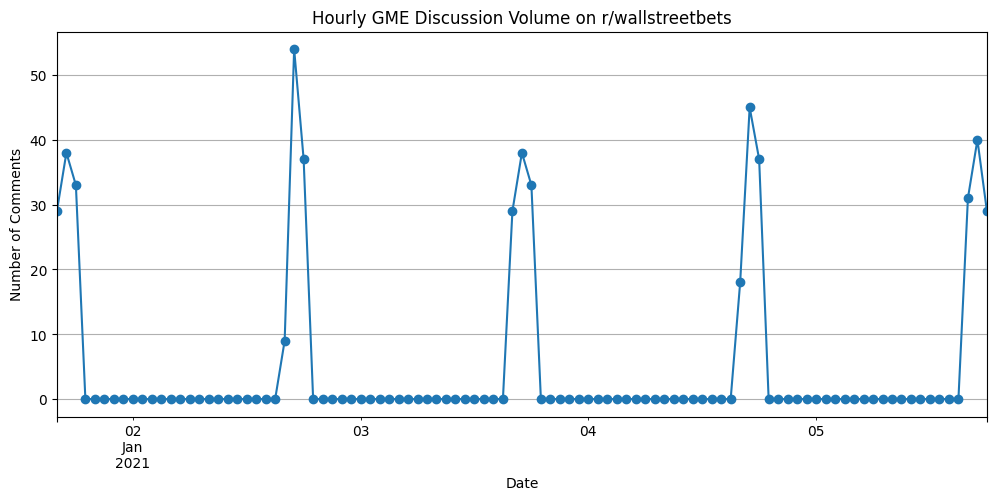

In [ ]:
hourly_comments = (
    df.set_index("datetime_et")
      .resample("1h")
      .size()
)

hourly_comments.plot(
    figsize=(12, 5),
    marker="o",
    xlabel="Date",
    ylabel="Number of Comments",
    title="Hourly GME Discussion Volume on r/wallstreetbets",
    grid=True
)

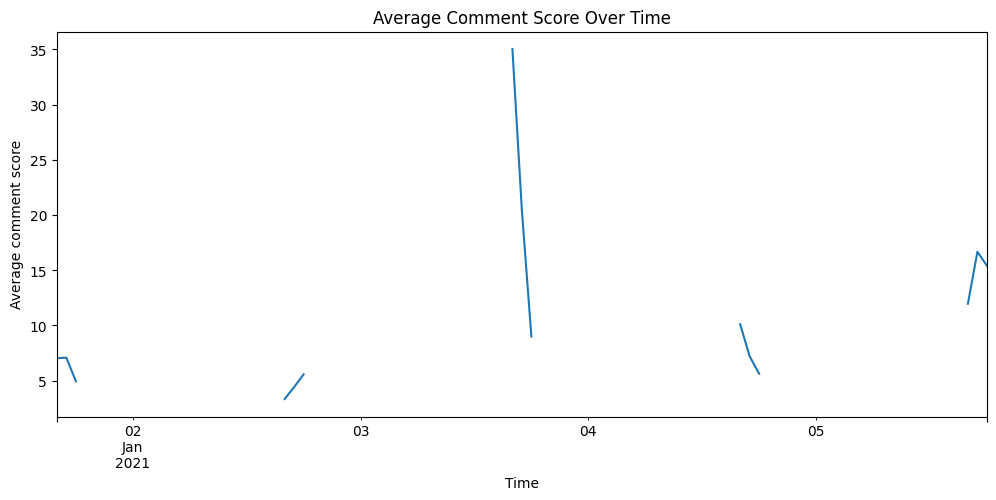

In [ ]:
hourly_score = (
    df.set_index("datetime_et")["score"]
      .resample("1h")
      .mean()
)

ax = hourly_score.plot(
    figsize=(12, 5),
    xlabel="Time",
    ylabel="Average comment score",
    title="Average Comment Score Over Time"
)

In [ ]:
hourly_stats = (
    df.set_index("datetime_et")
      .resample("1h")
      .agg(
          comments=("id", "count"),
          avg_score=("score", "mean"),
          unique_authors=("author", "nunique")
      )
)

display(hourly_stats.head())

,comments,avg_score,unique_authors
datetime_et,,,
2021-01-01 16:00:00-05:00,29,7.034483,26
2021-01-01 17:00:00-05:00,38,7.078947,33
2021-01-01 18:00:00-05:00,33,4.939394,26
2021-01-01 19:00:00-05:00,0,NaN,0
2021-01-01 20:00:00-05:00,0,NaN,0


<Axes: title={'center': 'Daily Unique Authors Discussing GME'}, xlabel='Date', ylabel='Number of Unique Authors'>

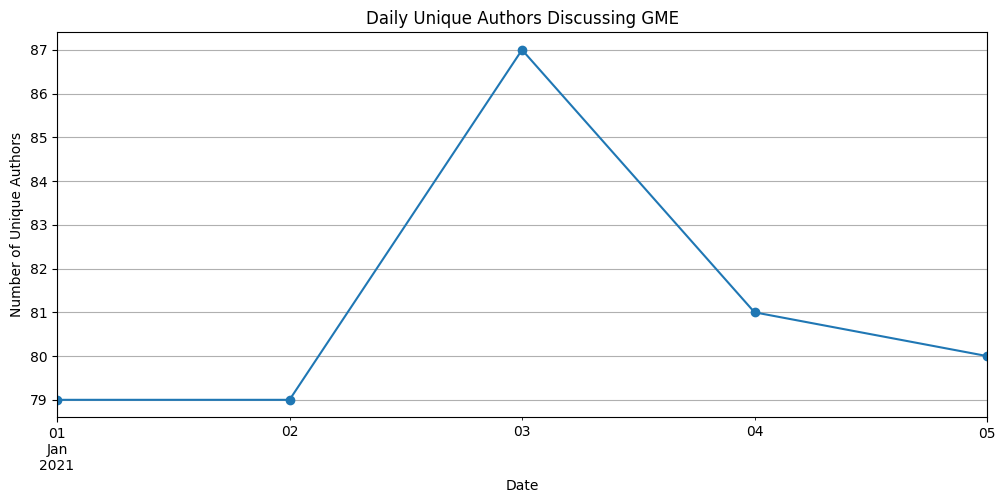

In [ ]:
daily_authors = (
    df.set_index("datetime_et")["author"]
      .resample("D")
      .nunique()
)

daily_authors.plot(
    figsize=(12, 5),
    marker="o",
    xlabel="Date",
    ylabel="Number of Unique Authors",
    title="Daily Unique Authors Discussing GME",
    grid=True
)

## Preview of the text data

### Functions we need

In [ ]:
def prepare_comments(df, timezone="America/New_York"):
    """Convert Unix timestamps to human-readable datetime."""
    df = df.copy()
    df["datetime"] = pd.to_datetime(
        df["created_utc"], unit="s", utc=True
    ).dt.tz_convert(timezone)
    return df


def aggregate_comments(df, freq="D"):
    """Aggregate comments by time period: 'D' = daily, 'h' = hourly."""
    df = prepare_comments(df)

    return (
        df.set_index("datetime")
          .resample(freq)
          .agg(
              comments=("id", "count"),
              avg_score=("score", "mean"),
              unique_authors=("author", "nunique")
          )
    )


def plot_stat(df, stat="comments", freq="D", label=None):
    """
    Plot one statistic for one DataFrame.

    stat: 'comments', 'avg_score', or 'unique_authors'
    freq: 'D' for daily, 'h' for hourly, 'W' for weekly
    label: optional dataset name for the plot title
    """
    stats = aggregate_comments(df, freq=freq)

    titles = {
        "comments": "Discussion Volume",
        "avg_score": "Average Comment Score",
        "unique_authors": "Unique Authors"
    }

    ylabels = {
        "comments": "Number of Comments",
        "avg_score": "Average Score",
        "unique_authors": "Number of Unique Authors"
    }

    if stat not in titles:
        raise ValueError(f"stat must be one of {list(titles)}")

    title = titles[stat]
    if label:
        title = f"{title} — {label}"

    ax = stats[stat].plot(
        figsize=(12, 5),
        marker="o"
    )

    ax.set_title(title)
    ax.set_xlabel("Date and Time")
    ax.set_ylabel(ylabels[stat])
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return stats

def compare_stat(datasets, stat="comments", freq="D", log_y=False):
    """
    Compare one statistic across multiple DataFrames.

    Parameters
    ----------
    datasets : dict
        Dictionary mapping dataset labels to DataFrames.
    stat : str
        Statistic to compare, e.g. "comments", "avg_score", or "unique_authors".
    freq : str
        Aggregation frequency, e.g. "D" (daily) or "h" (hourly).
    log_y : bool
        If True, use a logarithmic y-axis.
    """
    plt.figure(figsize=(12, 5))

    for label, df in datasets.items():
        stats = aggregate_comments(df, freq=freq)
        plt.plot(stats.index, stats[stat], marker="o", label=label)

    if log_y:
        plt.yscale("log")

    plt.xlabel("Date and Time")
    plt.ylabel(stat.replace("_", " ").title())
    plt.title(f"{stat.replace('_', ' ').title()} Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Trial A

In [ ]:
df_gme1 = pd.read_csv(f"{project_path}/wallstreetbets_GME_Jan2021_Jan1_Jan5.csv")
df_gme2 = pd.read_csv(f"{project_path}/wallstreetbets_GME_Jan2021_Feb1_Mar10.csv")

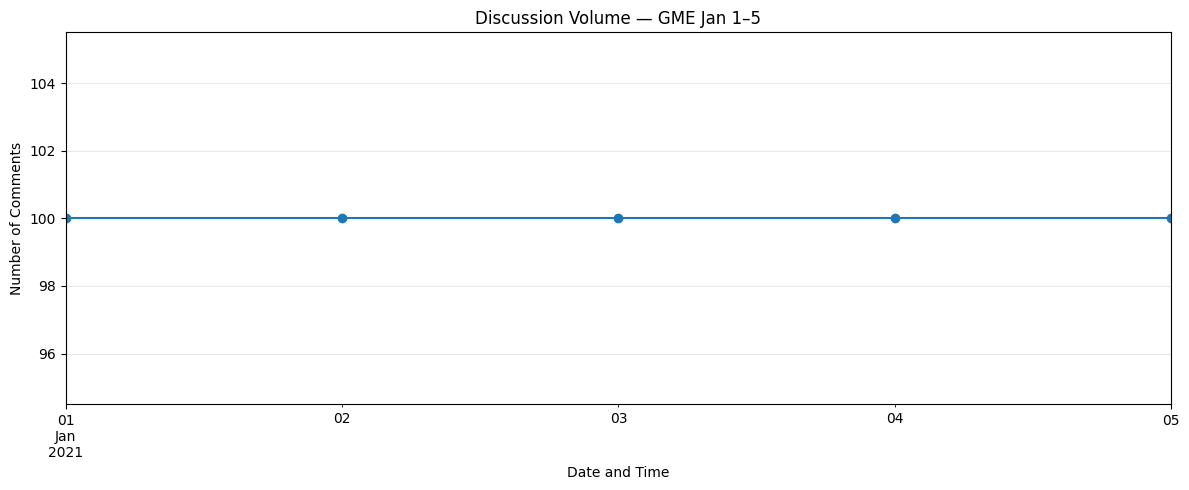

,comments,avg_score,unique_authors
datetime,,,
2021-01-01 00:00:00-05:00,100,6.36,79
2021-01-02 00:00:00-05:00,100,4.75,79
2021-01-03 00:00:00-05:00,100,20.88,87
2021-01-04 00:00:00-05:00,100,7.14,81
2021-01-05 00:00:00-05:00,100,14.85,80


In [ ]:
plot_stat(df_gme1, stat="comments", freq="D", label="GME Jan 1–5")

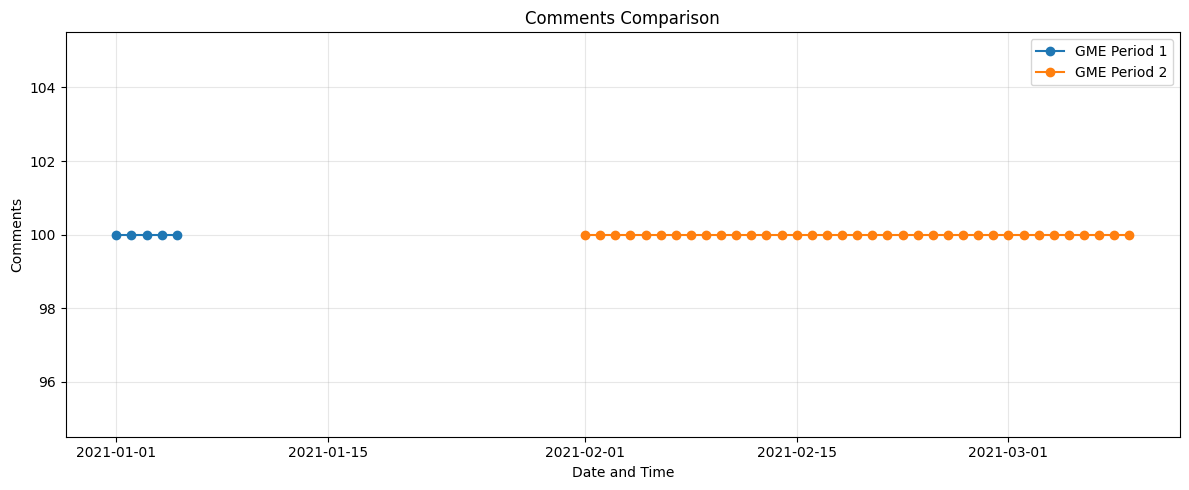

In [ ]:
compare_stat({
    "GME Period 1": df_gme1,
    "GME Period 2": df_gme2,
}, stat="comments", freq="D")

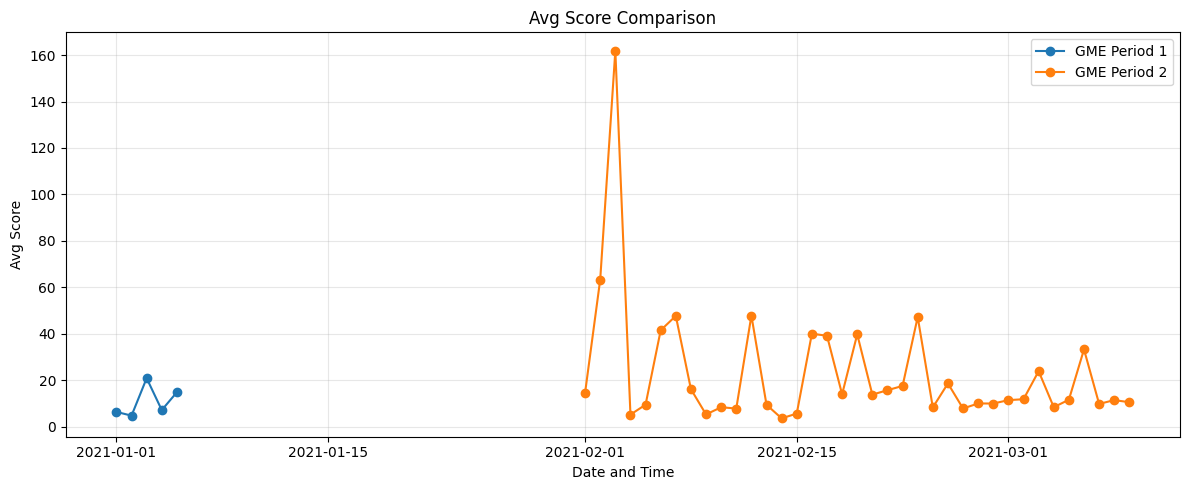

In [ ]:
compare_stat({
    "GME Period 1": df_gme1,
    "GME Period 2": df_gme2,
}, stat="avg_score", freq="D")

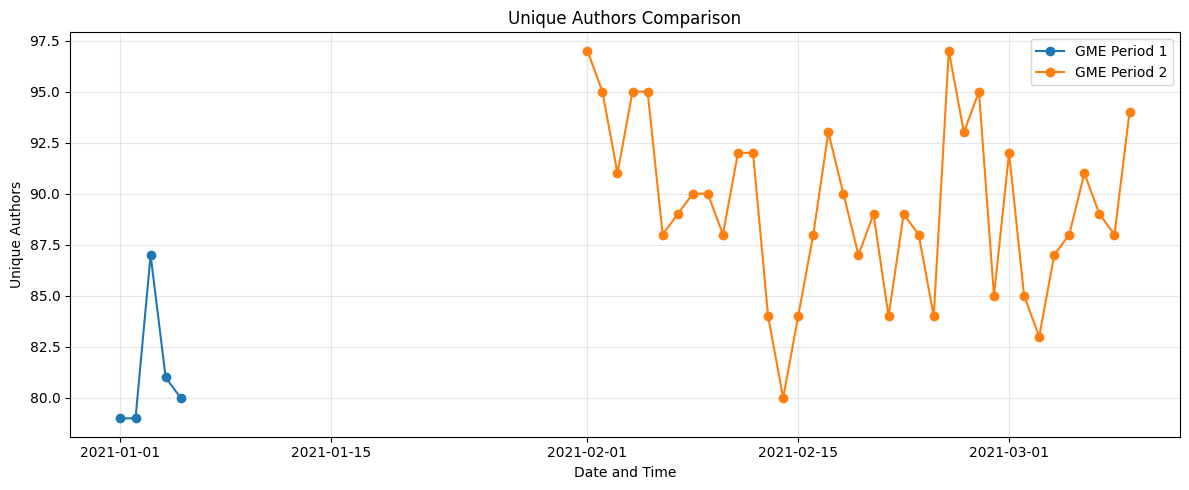

In [ ]:
compare_stat({
    "GME Period 1": df_gme1,
    "GME Period 2": df_gme2,
}, stat="unique_authors", freq="D")

### Trial B

In [ ]:
df_gme1 = pd.read_csv(f"{project_path}/wallstreetbets_GME_Jan4_2021_Apr12_2021_CappedAt100PerDay.csv")
df_bb1 = pd.read_csv(f"{project_path}/wallstreetbets_BB_Nov30_2020_Dec9_2020.csv")
df_bb2 = pd.read_csv(f"{project_path}/wallstreetbets_BB_Jan13_2021_Feb9_2021.csv")
df_bb3 = pd.read_csv(f"{project_path}/wallstreetbets_BB_Feb25_2021_Jun21_2021.csv")
df_amc1 = pd.read_csv(f"{project_path}/wallstreetbets_AMC_Jan4_2021_Feb25_2021.csv")
df_amc2 = pd.read_csv(f"{project_path}/wallstreetbets_AMC_Feb24_2021_Apr5_2021.csv")
df_amc3 = pd.read_csv(f"{project_path}/wallstreetbets_AMC_May3_2021_Jul5_2021.csv")

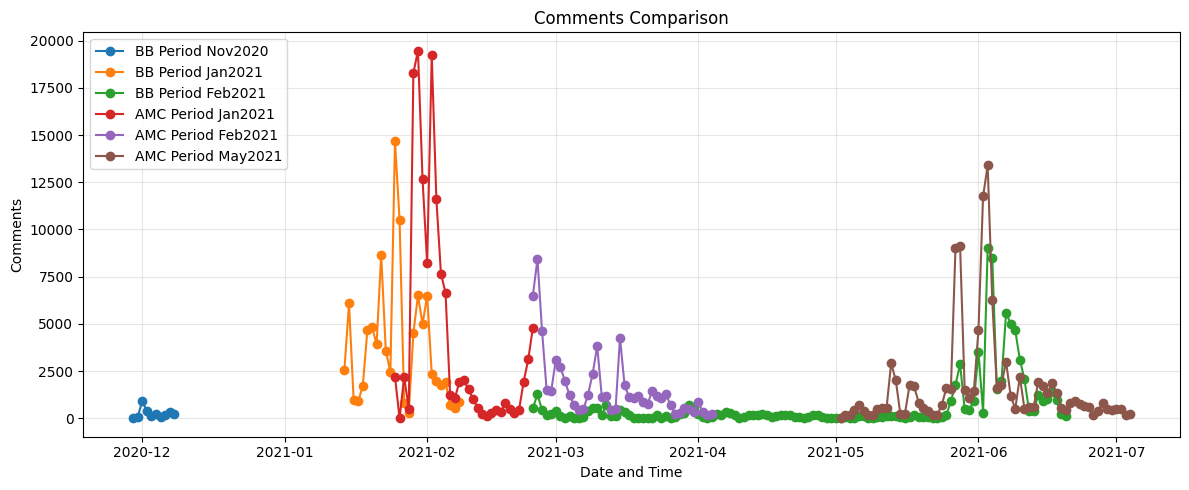

In [ ]:
compare_stat({
    "BB Period Nov2020": df_bb1,
    "BB Period Jan2021": df_bb2,
    "BB Period Feb2021": df_bb3,
    "AMC Period Jan2021": df_amc1,
    "AMC Period Feb2021": df_amc2,
    "AMC Period May2021": df_amc3,
}, stat="comments", freq="D")

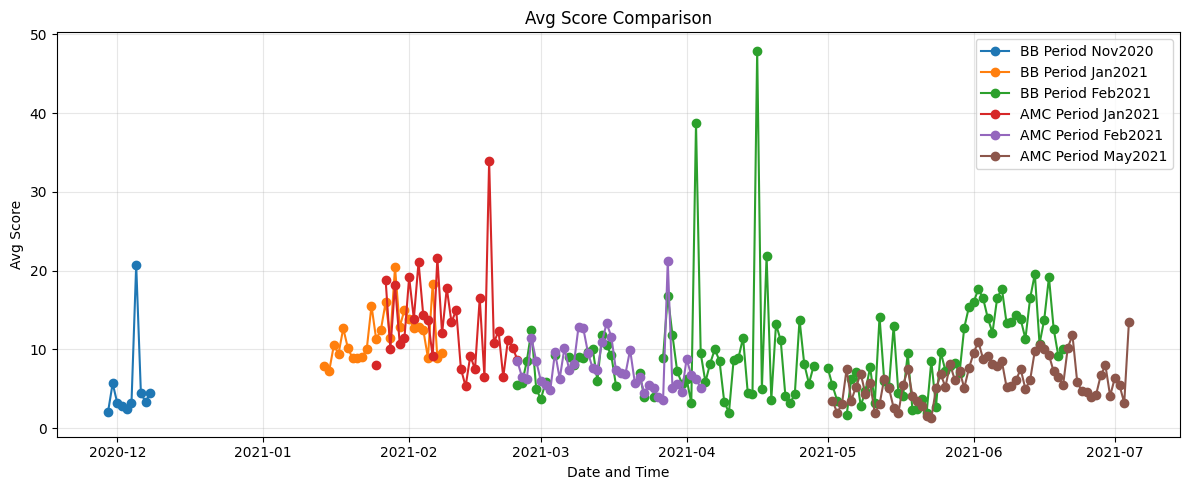

In [ ]:
compare_stat({
    "BB Period Nov2020": df_bb1,
    "BB Period Jan2021": df_bb2,
    "BB Period Feb2021": df_bb3,
    "AMC Period Jan2021": df_amc1,
    "AMC Period Feb2021": df_amc2,
    "AMC Period May2021": df_amc3,
}, stat="avg_score", freq="D")

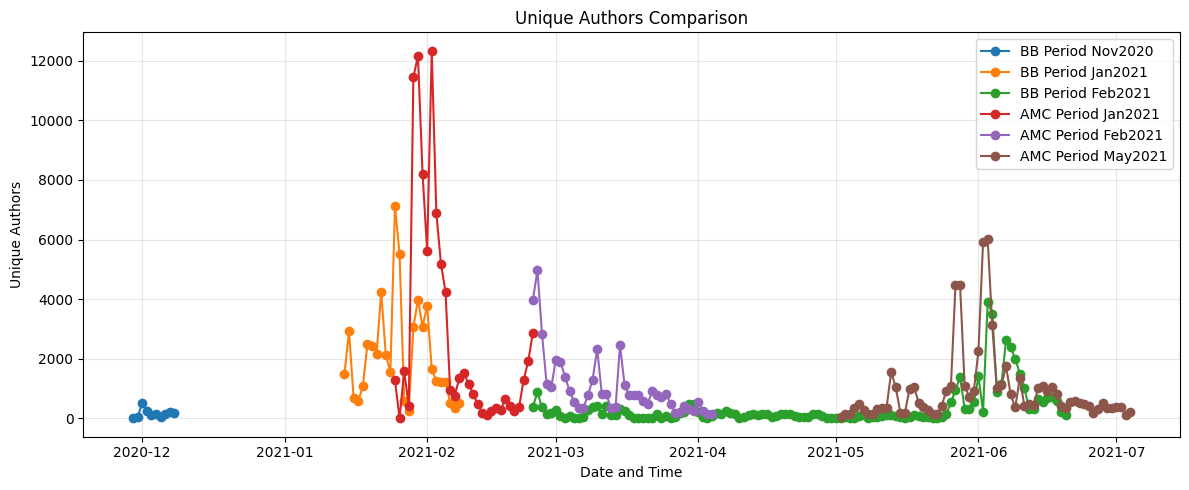

In [ ]:
compare_stat({
    "BB Period Nov2020": df_bb1,
    "BB Period Jan2021": df_bb2,
    "BB Period Feb2021": df_bb3,
    "AMC Period Jan2021": df_amc1,
    "AMC Period Feb2021": df_amc2,
    "AMC Period May2021": df_amc3,
}, stat="unique_authors", freq="D")

## Others